<a href="https://colab.research.google.com/github/beingAnujChaudhary/Customer-Churn-Prediction-Retention-Prioritization/blob/main/notebooks/02_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# %% [markdown]
# # 🤖 Stage 5: Baseline Modeling
# *Notebook: 02_modeling.ipynb*
#
# **Purpose**: Train & compare Logistic Regression, Random Forest, and XGBoost

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)
import joblib
import os

print("✓ Libraries loaded")

✓ Libraries loaded


In [5]:
# %% [code]
# LOAD PROCESSED DATA
df = pd.read_csv("data/processed/customers_v3.csv")

# Split train/test
train_df = df[df["split"] == "train"].drop(columns=["split"])
test_df = df[df["split"] == "test"].drop(columns=["split"])

# Separate features & target
X_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]
X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]

print(f"✅ Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"   Churn rate - Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

✅ Train: 8101 samples | Test: 2026 samples
   Churn rate - Train: 16.07% | Test: 16.04%


In [6]:
# %% [code]
# TRAIN & EVALUATE MODEL
def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name):
    """Train model and return metrics"""

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_pred_proba)
    }

    print(f"\n{'='*60}")
    print(f"📊 {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall:    {metrics['Recall']:.4f}")
    print(f"F1-Score:  {metrics['F1-Score']:.4f}")
    print(f"AUC:       {metrics['AUC']:.4f}")
    print(f"{'='*60}\n")

    return model, metrics, y_pred_proba

In [7]:
# %% [code]
# MODEL 1: LOGISTIC REGRESSION (BASELINE)
print("🚀 Training Logistic Regression...")
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced',  # Handle class imbalance
    solver='lbfgs'
)

lr_model, lr_metrics, lr_proba = train_and_evaluate(
    lr_model, X_train, y_train, X_test, y_test,
    "Logistic Regression"
)

# Save model
os.makedirs("output/models", exist_ok=True)
joblib.dump(lr_model, "output/models/logistic_regression.pkl")
print("✅ Saved: output/models/logistic_regression.pkl")

🚀 Training Logistic Regression...

📊 Logistic Regression
Accuracy:  0.8421
Precision: 0.5048
Recall:    0.8123
F1-Score:  0.6226
AUC:       0.9173

✅ Saved: output/models/logistic_regression.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
# %% [code]
# MODEL 2: RANDOM FOREST
print("🚀 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1  # Use all CPU cores
)

rf_model, rf_metrics, rf_proba = train_and_evaluate(
    rf_model, X_train, y_train, X_test, y_test,
    "Random Forest"
)

# Save model
joblib.dump(rf_model, "output/models/random_forest.pkl")
print("✅ Saved: output/models/random_forest.pkl")

🚀 Training Random Forest...

📊 Random Forest
Accuracy:  0.9482
Precision: 0.8416
Recall:    0.8338
F1-Score:  0.8377
AUC:       0.9833

✅ Saved: output/models/random_forest.pkl


In [9]:
# %% [code]
# MODEL 3: XGBOOST (FINAL)
import xgboost as xgb

print("🚀 Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # Handle imbalance
    eval_metric='auc',
    use_label_encoder=False
)

xgb_model, xgb_metrics, xgb_proba = train_and_evaluate(
    xgb_model, X_train, y_train, X_test, y_test,
    "XGBoost"
)

# Save model
joblib.dump(xgb_model, "output/models/xgboost.pkl")
print("✅ Saved: output/models/xgboost.pkl")

🚀 Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:29:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 XGBoost
Accuracy:  0.9684
Precision: 0.8872
Recall:    0.9200
F1-Score:  0.9033
AUC:       0.9927

✅ Saved: output/models/xgboost.pkl


In [10]:
# %% [code]
# MODEL 3: XGBOOST (FINAL)
import xgboost as xgb

print("🚀 Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # Handle imbalance
    eval_metric='auc',
    use_label_encoder=False
)

xgb_model, xgb_metrics, xgb_proba = train_and_evaluate(
    xgb_model, X_train, y_train, X_test, y_test,
    "XGBoost"
)

# Save model
joblib.dump(xgb_model, "output/models/xgboost.pkl")
print("✅ Saved: output/models/xgboost.pkl")

🚀 Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:30:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 XGBoost
Accuracy:  0.9684
Precision: 0.8872
Recall:    0.9200
F1-Score:  0.9033
AUC:       0.9927

✅ Saved: output/models/xgboost.pkl


In [11]:
# %% [code]
# MODEL COMPARISON
results_df = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics])
results_df = results_df.set_index("Model")

print("\n📊 MODEL COMPARISON TABLE")
print("="*70)
print(results_df.round(4).to_string())
print("="*70)

# Identify best model
best_model = results_df.loc[results_df["AUC"].idxmax()]
print(f"\n🏆 Best Model: {best_model.name}")
print(f"   AUC: {best_model['AUC']:.4f} | F1: {best_model['F1-Score']:.4f}")


📊 MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score     AUC
Model                                                             
Logistic Regression    0.8421     0.5048  0.8123    0.6226  0.9173
Random Forest          0.9482     0.8416  0.8338    0.8377  0.9833
XGBoost                0.9684     0.8872  0.9200    0.9033  0.9927

🏆 Best Model: XGBoost
   AUC: 0.9927 | F1: 0.9033


In [14]:
import os

# Create output directories
os.makedirs("output/plots", exist_ok=True)
os.makedirs("output/models", exist_ok=True)

print("✅ Directories created:")
print("   - output/plots/")
print("   - output/models/")

✅ Directories created:
   - output/plots/
   - output/models/


✅ Directories ready


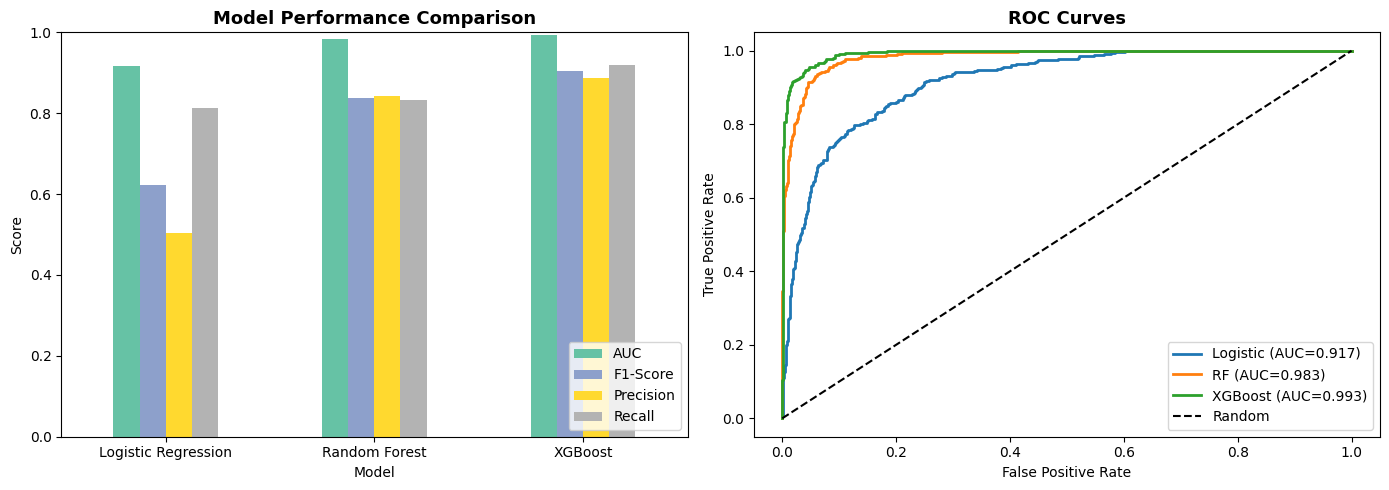

✅ Saved: output/plots/model_comparison.png


In [16]:
# %% [code]
# VISUALIZE: Model Comparison
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# ✅ CREATE DIRECTORIES FIRST
os.makedirs("output/plots", exist_ok=True)
os.makedirs("output/models", exist_ok=True)
print("✅ Directories ready")

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: AUC comparison
metrics_to_compare = ['AUC', 'F1-Score', 'Precision', 'Recall']
results_df[metrics_to_compare].plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim([0, 1])
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=0)

# ROC Curves
axes[1].plot(roc_curve(y_test, lr_proba)[0], roc_curve(y_test, lr_proba)[1],
             label=f'Logistic (AUC={lr_metrics["AUC"]:.3f})', linewidth=2)
axes[1].plot(roc_curve(y_test, rf_proba)[0], roc_curve(y_test, rf_proba)[1],
             label=f'RF (AUC={rf_metrics["AUC"]:.3f})', linewidth=2)
axes[1].plot(roc_curve(y_test, xgb_proba)[0], roc_curve(y_test, xgb_proba)[1],
             label=f'XGBoost (AUC={xgb_metrics["AUC"]:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()

# Display inline (so you can see it in notebook)
plt.show()

# Save to file
plt.savefig("output/plots/model_comparison.png", dpi=300, bbox_inches='tight')
plt.close()

print("✅ Saved: output/plots/model_comparison.png")

In [17]:
# %% [code]
# SAVE PREDICTIONS FOR SHAP ANALYSIS (Stage 7)
predictions_df = pd.DataFrame({
    "customer_id": range(len(y_test)),
    "actual_churn": y_test.values,
    "predicted_proba_lr": lr_proba,
    "predicted_proba_rf": rf_proba,
    "predicted_proba_xgb": xgb_proba,
    "predicted_xgb": xgb_model.predict(X_test)
})

predictions_df.to_csv("output/predictions_stage5.csv", index=False)
print("✅ Saved: output/predictions_stage5.csv")
print(f"   Records: {len(predictions_df)}")

✅ Saved: output/predictions_stage5.csv
   Records: 2026
